### Models Training 

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("/Users/saif/Desktop/ML_Load_Forecasting/data/Gold/df_features_fourier_time_encoding.csv", index_col=0 , parse_dates=True)
print(df.head(3))
print(df.columns.tolist)


                      Load_MW  temperature_2m  wind_speed_10m  \
2020-01-07 23:00:00  55818.41             3.0            15.5   
2020-01-08 00:00:00  54220.74             2.5            15.9   
2020-01-08 01:00:00  52752.95             3.8            17.8   

                     shortwave_radiation  hour  dayofweek  month  is_weekend  \
2020-01-07 23:00:00                  0.0    23          1      1           0   
2020-01-08 00:00:00                  0.0     0          2      1           0   
2020-01-08 01:00:00                  0.0     1          2      1           0   

                     hour_sin  hour_cos  ...  month_sin  month_cos  \
2020-01-07 23:00:00 -0.258819  0.965926  ...        0.5   0.866025   
2020-01-08 00:00:00  0.000000  1.000000  ...        0.5   0.866025   
2020-01-08 01:00:00  0.258819  0.965926  ...        0.5   0.866025   

                     is_holiday  lag_hour   lag_day  lag_week  \
2020-01-07 23:00:00           0  54220.74  51875.48  57004.20   
2020-01

In [3]:
X = df.drop(columns=["Load_MW"])
y = df["Load_MW"]
print(X.head())
print(y.head())

                     temperature_2m  wind_speed_10m  shortwave_radiation  \
2020-01-07 23:00:00             3.0            15.5                  0.0   
2020-01-08 00:00:00             2.5            15.9                  0.0   
2020-01-08 01:00:00             3.8            17.8                  0.0   
2020-01-08 02:00:00             3.7            17.2                  0.0   
2020-01-08 03:00:00             3.7            19.8                  0.0   

                     hour  dayofweek  month  is_weekend  hour_sin  hour_cos  \
2020-01-07 23:00:00    23          1      1           0 -0.258819  0.965926   
2020-01-08 00:00:00     0          2      1           0  0.000000  1.000000   
2020-01-08 01:00:00     1          2      1           0  0.258819  0.965926   
2020-01-08 02:00:00     2          2      1           0  0.500000  0.866025   
2020-01-08 03:00:00     3          2      1           0  0.707107  0.707107   

                      day_sin  ...  month_sin  month_cos  is_holiday

In [4]:
X_train = X[X.index.year < 2023]
y_train = y[y.index.year < 2023]

X_test = X[X.index.year == 2023]
y_test = y[y.index.year == 2023]

In [5]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(26137, 21)
(8592, 21)
(26137,)
(8592,)


### Model 1 — Linear Regression:

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_lr_predict = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_lr_predict)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_lr_predict))
r2_lr = r2_score(y_test, y_lr_predict)

In [8]:
print(f"MAE: {mae_lr:.0f} MW | RMSE: {rmse_lr:.0f} MW | R²: {r2_lr:.4f}")

MAE: 1175 MW | RMSE: 1467 MW | R²: 0.9747


### Model 2 — Random forest:

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_rf_predict = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_rf_predict)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_rf_predict))
r2_rf = r2_score(y_test, y_rf_predict)

In [10]:
print(f"MAE: {mae_rf:.0f} MW | RMSE: {rmse_rf:.0f} MW | R²: {r2_rf:.4f}")

MAE: 584 MW | RMSE: 781 MW | R²: 0.9928


### XGBoost

In [11]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

xgb_model.fit(X_train, y_train)
y_xgb_predict = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_xgb_predict)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_xgb_predict))
r2_xgb = r2_score(y_test, y_xgb_predict)

In [12]:
print(f"MAE: {mae_xgb:.0f} MW | RMSE: {rmse_xgb:.0f} MW | R²: {r2_xgb:.4f}")

MAE: 549 MW | RMSE: 715 MW | R²: 0.9940


### SVM

In [13]:
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler

In [14]:
# Scaler 1 — für X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

# Scaler 2 — für y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# SVM trainieren
svm_model = LinearSVR(C=1.0, max_iter=10000)
svm_model.fit(X_train_scaled, y_train_scaled)

# Vorhersagen zurück transformieren
y_svm_predict_scaled = svm_model.predict(X_test_scaled)
y_svm_predict = scaler_y.inverse_transform(
    y_svm_predict_scaled.reshape(-1, 1)).ravel()

mae_svm  = mean_absolute_error(y_test, y_svm_predict)
rmse_svm = np.sqrt(mean_squared_error(y_test, y_svm_predict))
r2_svm   = r2_score(y_test, y_svm_predict)

/Users/saif/Desktop/ML_Load_Forecasting/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [15]:
print(f"MAE: {mae_svm:.0f} MW | RMSE: {rmse_svm:.0f} MW | R²: {r2_svm:.4f}")

MAE: 1131 MW | RMSE: 1452 MW | R²: 0.9752


### Plotting Results

/var/folders/c2/0pncj6ld4glby0b51j0k8dgc0000gn/T/ipykernel_25625/892120818.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="MAE", palette=colors, ax=axes[0])
/var/folders/c2/0pncj6ld4glby0b51j0k8dgc0000gn/T/ipykernel_25625/892120818.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="RMSE", palette=colors, ax=axes[1])
/var/folders/c2/0pncj6ld4glby0b51j0k8dgc0000gn/T/ipykernel_25625/892120818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="R²", palet

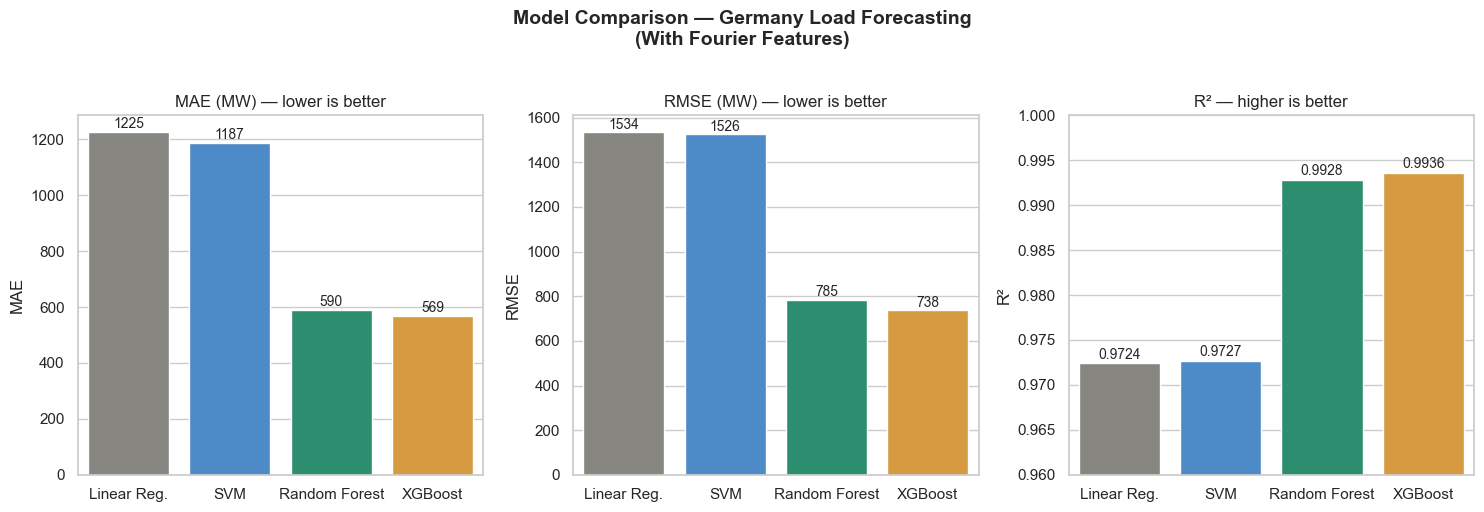

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid", palette="muted")

results = pd.DataFrame({
    "Model":  ["Linear Reg.", "SVM", "Random Forest", "XGBoost"],
    "MAE":    [1225, 1187, 590, 569],
    "RMSE":   [1534, 1526, 785, 738],
    "R²":     [0.9724, 0.9727, 0.9928, 0.9936]
})

colors = ["#888780", "#378ADD", "#1D9E75", "#EF9F27"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison — Germany Load Forecasting\n(With Fourier Features)",
             fontsize=14, fontweight="bold", y=1.02)

# MAE
sns.barplot(data=results, x="Model", y="MAE", palette=colors, ax=axes[0])
axes[0].set_title("MAE (MW) — lower is better", fontsize=12)
axes[0].set_xlabel("")
for bar, val in zip(axes[0].patches, results["MAE"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 15,
                 f"{val}", ha="center", fontsize=10, fontweight="500")

# RMSE
sns.barplot(data=results, x="Model", y="RMSE", palette=colors, ax=axes[1])
axes[1].set_title("RMSE (MW) — lower is better", fontsize=12)
axes[1].set_xlabel("")
for bar, val in zip(axes[1].patches, results["RMSE"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 15,
                 f"{val}", ha="center", fontsize=10, fontweight="500")

# R²
sns.barplot(data=results, x="Model", y="R²", palette=colors, ax=axes[2])
axes[2].set_title("R² — higher is better", fontsize=12)
axes[2].set_xlabel("")
axes[2].set_ylim(0.96, 1.0)
for bar, val in zip(axes[2].patches, results["R²"]):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0005,
                 f"{val:.4f}", ha="center", fontsize=10, fontweight="500")

plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/06_model_comparison_with_F_Features.png", dpi=150, bbox_inches="tight")
plt.show()

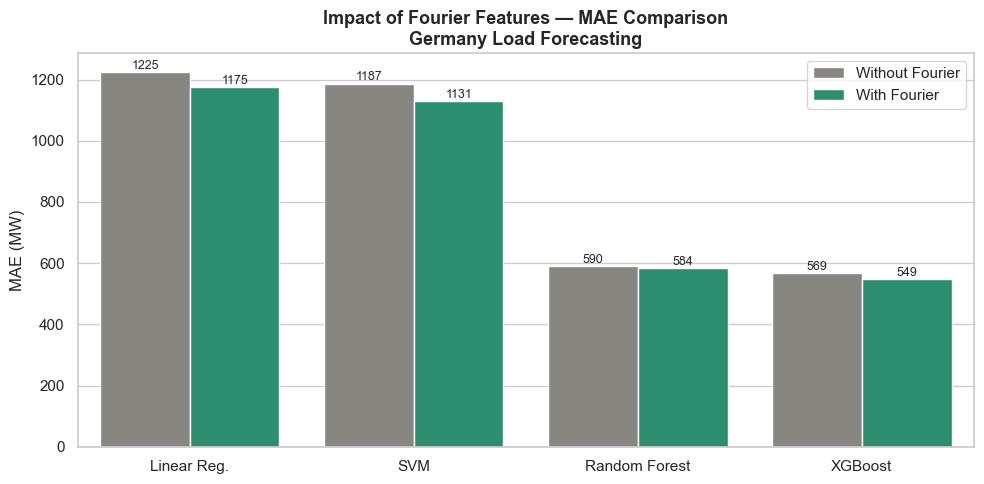

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid")

df_compare = pd.DataFrame({
    "Model": ["Linear Reg.", "SVM", "Random Forest", "XGBoost"] * 2,
    "MAE": [1225, 1187, 590, 569, 1175, 1131, 584, 549],
    "Features": ["Without Fourier"] * 4 + ["With Fourier"] * 4
})

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=df_compare, x="Model", y="MAE", 
            hue="Features",
            palette=["#888780", "#1D9E75"],
            ax=ax)

ax.set_title("Impact of Fourier Features — MAE Comparison\nGermany Load Forecasting",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("MAE (MW)")
ax.legend(title="")

for bar in ax.patches:
    height = bar.get_height()
    if height > 10:  # nur Balken mit echten Werten labeln
        ax.text(bar.get_x() + bar.get_width()/2,
                height + 10,
                f"{int(height)}",
                ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/07_fourier_comparison.png", dpi=150, bbox_inches="tight")
plt.show()